# HealthConnect Week 6 Model Improvement and Validation

Wilson Moses | Data Science Track | AnalystLab Africa

I build forward from Week 5 without replacing the original data or baseline. This notebook includes AI-assisted work and an explicitly simulated ML Engineering interaction requested by me. It does not evidence a human intern exchange. Run from this folder or the package root. Outputs are captured through sequential Python execution in one clean namespace.

The reports, integration evidence and Week 7 plan explain decisions and limitations. Existing generated Week 6 outputs are replaced on rerun. Only load the trusted model artifact supplied with this package.

## 1. Setup and continuity

**IBM Data Understanding.** I reuse the unchanged dataset and the exact Week 5 partitions. The old test is a comparison set, not a fresh holdout. Why must the same appointments be compared?

In [1]:
from pathlib import Path
import sys,json,hashlib,platform,joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score,average_precision_score,brier_score_loss,accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
BASE=Path.cwd() if (Path.cwd()/'src/healthconnect.py').exists() else Path.cwd().parent
sys.path.insert(0,str(BASE/'src'))
from healthconnect import features,score,BASE_NUM,CAT,REQUIRED
MET=BASE/'outputs/metrics';FIG=BASE/'outputs/figures'
MET.mkdir(parents=True,exist_ok=True);FIG.mkdir(parents=True,exist_ok=True)
raw=pd.read_csv(BASE/'data/raw/healthconnect_appointment_data.csv',keep_default_na=False)
x=features(raw)
cohort=raw.loc[raw.appointment_outcome.isin(['Attended','No-Show'])].copy()
X=x.loc[cohort.index];y=cohort.appointment_outcome.eq('No-Show').astype(int)
train_mask=X.appointment_date.lt('2026-03-01');test_mask=X.booking_date.ge('2026-03-01')
trainX=X.loc[train_mask];trainy=y.loc[train_mask];testX=X.loc[test_mask];testy=y.loc[test_mask]
old=pd.read_csv(BASE/'reference/week5_test_predictions.csv')
assert old.appointment_id.tolist()==raw.loc[testX.index,'appointment_id'].tolist()
assert len(trainX)==3682 and len(testX)==799
print('Week 5 partitions preserved:',len(trainX),len(testX),'purged',len(X)-len(trainX)-len(testX))
print('Existing March-June comparison set has already been inspected. No fresh holdout claim.')



Week 5 partitions preserved: 3682 799 purged 256
Existing March-June comparison set has already been inspected. No fresh holdout claim.


## 2. Predeclared competitors and temporal folds

**IBM Modelling and Evaluation.** I compare the historical-feature baseline, a no-history variant and two nonlinear alternatives. All imputation and scaling are fitted within each fold. Appointment outcomes must be known before validation bookings occur. Why would a random row split answer a different question?

In [2]:
def make_model(name):
    nums=BASE_NUM.copy();cats=CAT.copy()
    clf=LogisticRegression(C=1,max_iter=2000,random_state=42)
    if name=='No-history logistic':nums=[v for v in nums if v not in ['previous_appointments','prior_no_show_rate','no_prior_history']]
    if name in ['Random forest','Gradient boosting']:
        nums=['age','distance_to_clinic_km','previous_appointments','prior_no_show_rate','no_prior_history','lead_days'];cats=CAT+['weekday']
        if name=='Random forest':clf=RandomForestClassifier(n_estimators=200,max_depth=6,min_samples_leaf=25,max_features=1.0,random_state=42,n_jobs=1)
        else:clf=HistGradientBoostingClassifier(max_iter=120,max_leaf_nodes=7,min_samples_leaf=30,l2_regularization=2,learning_rate=.05,early_stopping=False,random_state=42)
    prep=ColumnTransformer([('numeric',Pipeline([('impute',SimpleImputer(strategy='median')),('scale',StandardScaler())]),nums),
       ('category',OneHotEncoder(handle_unknown='ignore',sparse_output=False),cats)])
    return Pipeline([('prep',prep),('classifier',clf)])
def metrics(truth,prob,t=.5):
    pred=np.asarray(prob)>=t;tn,fp,fn,tp=confusion_matrix(truth,pred,labels=[0,1]).ravel()
    return dict(n=len(truth),roc_auc=roc_auc_score(truth,prob) if len(set(truth))>1 else np.nan,
      average_precision=average_precision_score(truth,prob),brier=brier_score_loss(truth,prob),accuracy=accuracy_score(truth,pred),
      precision=precision_score(truth,pred,zero_division=0),recall=recall_score(truth,pred,zero_division=0),f1=f1_score(truth,pred,zero_division=0),
      tn=int(tn),fp=int(fp),fn=int(fn),tp=int(tp),flagged=int(pred.sum()),flag_rate=float(pred.mean()))
names=['Week 5 logistic','No-history logistic','Random forest','Gradient boosting']
folds=[('2025-09-01','2025-11-01'),('2025-11-01','2026-01-01'),('2026-01-01','2026-03-01')]
scores=[];out_of_time=[];fold_rows=[]
for k,(start,end) in enumerate(folds,1):
    a=trainX.appointment_date.lt(start);b=trainX.booking_date.ge(start)&trainX.booking_date.lt(end)
    assert trainX.loc[a,'appointment_date'].max()<trainX.loc[b,'booking_date'].min()
    fold_rows.append(dict(fold=k,cutoff=start,booking_end=end,train=int(a.sum()),validation=int(b.sum())))
    for name in names:
        m=make_model(name);m.fit(trainX.loc[a],trainy.loc[a]);prob=m.predict_proba(trainX.loc[b])[:,1]
        scores.append(dict(model=name,fold=k,**metrics(trainy.loc[b],prob)))
        out_of_time.extend(dict(model=name,fold=k,index=int(i),truth=int(trainy.loc[i]),probability=float(p)) for i,p in zip(trainX.loc[b].index,prob))
cv=pd.DataFrame(scores);oof=pd.DataFrame(out_of_time);foldtable=pd.DataFrame(fold_rows)
cv.to_csv(MET/'temporal_validation.csv',index=False);oof.to_csv(MET/'out_of_time_predictions.csv',index=False);foldtable.to_csv(MET/'fold_definitions.csv',index=False)
ranking=cv.groupby('model').agg(mean_auc=('roc_auc','mean'),auc_sd=('roc_auc','std'),mean_brier=('brier','mean')).sort_values(['mean_auc','mean_brier'],ascending=[False,True])
candidate=ranking.index[0]
ranking.to_csv(MET/'validation_ranking.csv');print(foldtable.to_string(index=False));print(ranking.round(4));print('Candidate selected using internal validation:',candidate)



 fold     cutoff booking_end  train  validation
    1 2025-09-01  2025-11-01   2118         530
    2 2025-11-01  2026-01-01   2689         467
    3 2026-01-01  2026-03-01   3170         281
                     mean_auc  auc_sd  mean_brier
model                                            
No-history logistic    0.6481  0.0084      0.2348
Week 5 logistic        0.6416  0.0316      0.2372
Gradient boosting      0.6370  0.0240      0.2385
Random forest          0.6323  0.0276      0.2394
Candidate selected using internal validation: No-history logistic


## 3. Operating threshold and uncertainty sensitivity

**IBM Evaluation.** I explore a 30% follow-up workload scenario on internal predictions and test the Sunday training policy on the same non-Sunday validation population. The capacity is hypothetical. How can increasing a threshold reduce both workload and recall?

In [3]:
selected=oof.loc[oof.model.eq(candidate)].copy()
# Illustrative staffing scenario: maximum 30 percent of validation records flagged.
# This is a modelling scenario, not a clinic-approved capacity requirement.
thresholds=[]
for threshold in np.linspace(0,1,201):thresholds.append(dict(threshold=float(threshold),**metrics(selected.truth,selected.probability,threshold)))
threshold_table=pd.DataFrame(thresholds);eligible=threshold_table.loc[threshold_table.flag_rate.le(.30)]
threshold=float(eligible.sort_values(['recall','precision','threshold'],ascending=[False,False,True]).iloc[0].threshold)
threshold_table.to_csv(MET/'threshold_scenarios.csv',index=False)
sensitivity=[]
for flag in [False,True]:
    for k,(start,end) in enumerate(folds,1):
        a=trainX.appointment_date.lt(start);b=trainX.booking_date.ge(start)&trainX.booking_date.lt(end)
        # Assess the same non-Sunday validation population under two training policies.
        b &= trainX.appointment_date.dt.dayofweek.ne(6)
        if flag:a &= trainX.appointment_date.dt.dayofweek.ne(6)
        m=make_model(candidate);m.fit(trainX.loc[a],trainy.loc[a]);pr=m.predict_proba(trainX.loc[b])[:,1]
        sensitivity.append(dict(exclude_sunday_training=flag,fold=k,**metrics(trainy.loc[b],pr)))
pd.DataFrame(sensitivity).to_csv(MET/'sunday_sensitivity.csv',index=False)
print('Illustrative 30% validation-workload threshold:',threshold)
print(threshold_table.loc[threshold_table.threshold.eq(threshold)].round(4).to_string(index=False))



Illustrative 30% validation-workload threshold: 0.6
 threshold    n  roc_auc  average_precision  brier  accuracy  precision  recall     f1  tn  fp  fn  tp  flagged  flag_rate
       0.6 1278   0.6497             0.6286 0.2343    0.5869     0.6531   0.376 0.4772 509 128 400 241      369     0.2887


## 4. Reused comparison set and preserved baseline

**IBM Evaluation.** I refit candidates on all Week 5 training records and compare them on the previously exposed set. Candidate selection has already happened internally. Why does a higher value here not justify switching candidates after seeing the test results?

In [4]:
fitted={};comparisons=[];predframe=cohort.loc[testX.index,['appointment_id','patient_id','gender','age_group','appointment_type']].copy();predframe['truth']=testy
for name in names:
    m=make_model(name);m.fit(trainX,trainy);fitted[name]=m;pr=m.predict_proba(testX)[:,1]
    comparisons.append(dict(model=name,threshold=.5,**metrics(testy,pr)))
    predframe[name]=pr
np.testing.assert_allclose(predframe['Week 5 logistic'],old['Logistic regression_probability'],atol=1e-12)
prob=predframe[candidate].to_numpy();comparisons.append(dict(model=candidate+' capacity scenario',threshold=threshold,**metrics(testy,prob,threshold)))
comparison=pd.DataFrame(comparisons);comparison.to_csv(MET/'reused_test_comparison.csv',index=False)
predframe['candidate_prediction']=(prob>=.5).astype(int)
predframe['error_type']=np.select([(testy==1)&(prob<.5),(testy==0)&(prob>=.5)],['False negative','False positive'],default='Correct')
predframe.to_csv(MET/'reused_test_predictions.csv',index=False)
print(comparison.round(4).to_string(index=False))



                                model  threshold   n  roc_auc  average_precision  brier  accuracy  precision  recall     f1  tn  fp  fn  tp  flagged  flag_rate
                      Week 5 logistic        0.5 799   0.6678             0.6586 0.2290    0.6083     0.5885  0.6357 0.6112 240 172 141 246      418     0.5232
                  No-history logistic        0.5 799   0.6653             0.6503 0.2304    0.6108     0.5856  0.6718 0.6258 228 184 127 260      444     0.5557
                        Random forest        0.5 799   0.6672             0.6464 0.2280    0.6183     0.6133  0.5736 0.5928 272 140 165 222      362     0.4531
                    Gradient boosting        0.5 799   0.6655             0.6479 0.2285    0.6045     0.5989  0.5556 0.5764 268 144 172 215      359     0.4493
No-history logistic capacity scenario        0.6 799   0.6653             0.6503 0.2304    0.6145     0.7047  0.3514 0.4690 355  57 251 136      193     0.2416


## 5. Error analysis using observed segments, not causal claims

**IBM Data Understanding and Evaluation.** I inspect false positives and negatives across segments with counts. These patterns guide investigation but do not establish causes or fairness. Which denominator defines the false-positive rate?

In [5]:
errors=[]
for name in ['Week 5 logistic',candidate]:
    for field in ['gender','age_group','appointment_type']:
        for group,part in predframe.groupby(field):
            met=metrics(part.truth,part[name]);met['false_positive_rate']=met['fp']/(met['fp']+met['tn']) if met['fp']+met['tn'] else np.nan
            errors.append(dict(model=name,field=field,group=group,**met))
error_table=pd.DataFrame(errors).drop_duplicates();error_table.to_csv(MET/'segment_error_analysis.csv',index=False)
detail=predframe[['appointment_id','error_type','truth']].join(testX[['lead_days','prior_no_show_rate','age','distance_to_clinic_km']])
detail.groupby('error_type').agg(n=('truth','size'),lead_median=('lead_days','median'),prior_rate_median=('prior_no_show_rate','median'),age_median=('age','median')).to_csv(MET/'error_profiles.csv')
print(pd.read_csv(MET/'error_profiles.csv').to_string(index=False))
print('Segment comparisons are descriptive; no causal explanation or proven fairness.')



    error_type   n  lead_median  prior_rate_median  age_median
       Correct 488         24.0                0.0        47.5
False negative 127         12.0                0.0        45.0
False positive 184         34.0                0.0        52.0
Segment comparisons are descriptive; no causal explanation or proven fairness.


## 6. Serialize the selected preprocessing and model together

**IBM Deployment preparation.** The AI-simulated ML Engineering review requires a reusable artifact and a raw-data interface. I serialize preprocessing with the model and compare reloaded predictions. This is local integration, not production deployment. Why must preprocessing travel with the classifier?

In [6]:
obj=dict(pipeline=fitted[candidate],threshold=threshold,version='healthconnect-week6-v1',candidate=candidate,
         requires_history=candidate!='No-history logistic',known_categories={c:sorted(trainX[c].unique().tolist()) for c in CAT})
(BASE/'models').mkdir(exist_ok=True);joblib.dump(obj,BASE/'models/candidate_pipeline.joblib')
input_columns=REQUIRED if obj['requires_history'] else [c for c in REQUIRED if c not in ['previous_appointments','previous_no_shows']]
sample=raw.loc[testX.index[:5],input_columns];sample.to_csv(BASE/'integration/sample_input.csv',index=False)
scored=score(sample,BASE/'models/candidate_pipeline.joblib');scored.to_csv(BASE/'integration/sample_output.csv',index=False)
np.testing.assert_allclose(scored.no_show_probability,fitted[candidate].predict_proba(features(sample,require_history=obj['requires_history']))[:,1],atol=1e-12)
print(scored.to_string(index=False))



appointment_id  no_show_probability  support_flag  threshold          model_version                                    warnings
      HC-00024             0.512680             0        0.6 healthconnect-week6-v1                          experimental_model
      HC-00028             0.283509             0        0.6 healthconnect-week6-v1                          experimental_model
      HC-00035             0.150807             0        0.6 healthconnect-week6-v1                          experimental_model
      HC-00046             0.462347             0        0.6 healthconnect-week6-v1                          experimental_model
      HC-00048             0.522223             0        0.6 healthconnect-week6-v1 experimental_model;sunday_schedule_conflict


## 7. Evidence figures and run metadata

**IBM Evaluation and Feedback planning.** I export traceable figures and metadata. Fold standard deviations describe variation across three correlated temporal folds; they are not confidence intervals. What new evidence is required before deployment?

{
  "candidate": "No-history logistic",
  "threshold": 0.6,
  "raw_sha256": "1f2c40ae14833b46fe6e1a353446a0e038f19ae06434b37d98545b3e28697137",
  "train": 3682,
  "reused_test": 799,
  "folds": [
    {
      "fold": 1,
      "cutoff": "2025-09-01",
      "booking_end": "2025-11-01",
      "train": 2118,
      "validation": 530
    },
    {
      "fold": 2,
      "cutoff": "2025-11-01",
      "booking_end": "2026-01-01",
      "train": 2689,
      "validation": 467
    },
    {
      "fold": 3,
      "cutoff": "2026-01-01",
      "booking_end": "2026-03-01",
      "train": 3170,
      "validation": 281
    }
  ],
  "validation": [
    {
      "model": "No-history logistic",
      "mean_auc": 0.6480823338949754,
      "auc_sd": 0.008363425137434887,
      "mean_brier": 0.2348381507124422
    },
    {
      "model": "Week 5 logistic",
      "mean_auc": 0.6416157819527314,
      "auc_sd": 0.031638301224464385,
      "mean_brier": 0.23715500579338014
    },
    {
      "model": "Gradient bo

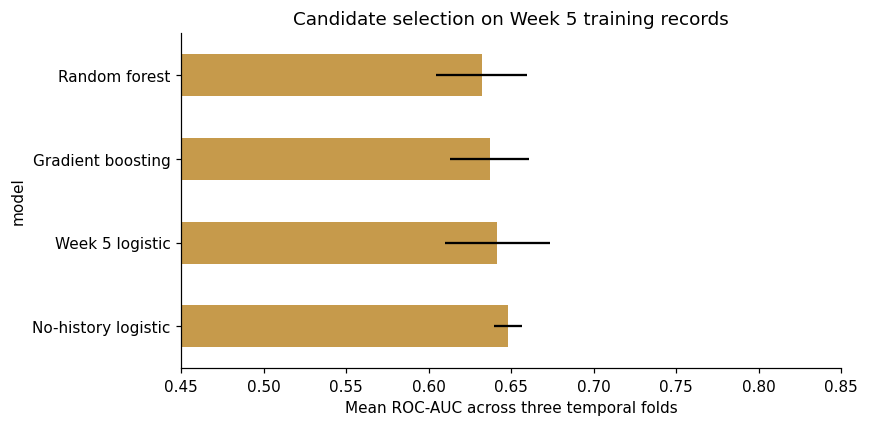

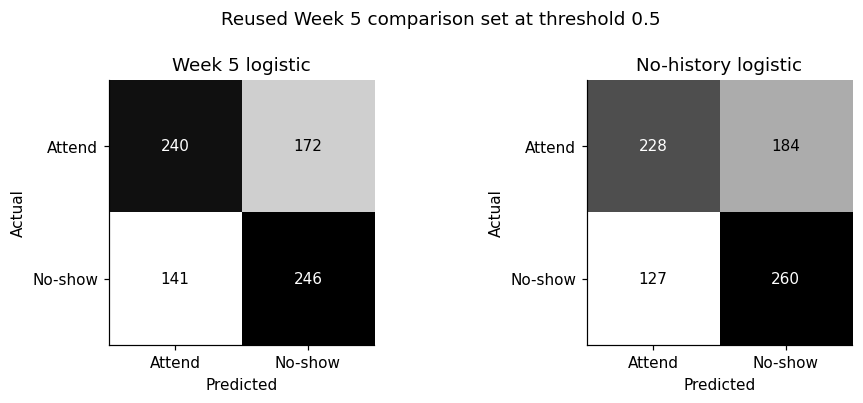

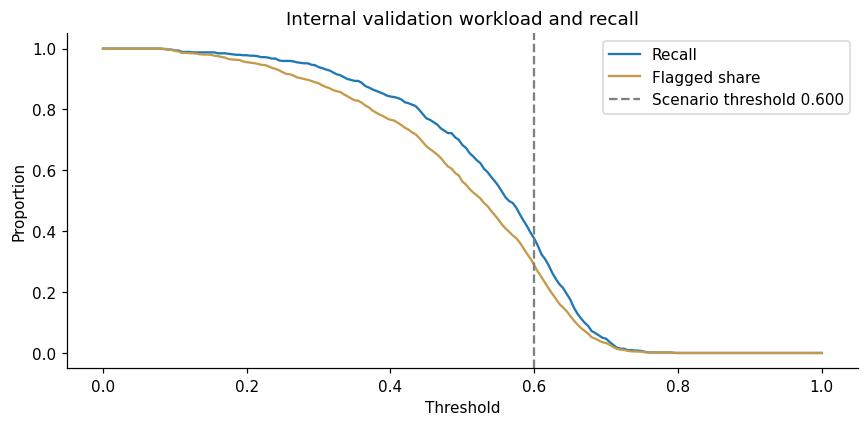

In [7]:
plt.rcParams.update({'font.size':10,'axes.spines.top':False,'axes.spines.right':False})
fig,ax=plt.subplots(figsize=(8,4));ranking.mean_auc.plot.barh(ax=ax,color='#C69A4B',xerr=ranking.auc_sd)
ax.set(xlabel='Mean ROC-AUC across three temporal folds',title='Candidate selection on Week 5 training records',xlim=(.45,.85));fig.tight_layout();fig.savefig(FIG/'01_validation_comparison.png',dpi=170);plt.show()
fig,axes=plt.subplots(1,2,figsize=(9,3.7))
for i,name in enumerate(['Week 5 logistic',candidate]):
    cm=confusion_matrix(testy,predframe[name]>=.5,labels=[0,1]);axes[i].imshow(cm,cmap='Greys')
    for a in range(2):
        for b in range(2):axes[i].text(b,a,str(cm[a,b]),ha='center',va='center',color='white' if cm[a,b]>(cm.min()+cm.max())/2 else 'black')
    axes[i].set(xticks=[0,1],yticks=[0,1],xticklabels=['Attend','No-show'],yticklabels=['Attend','No-show'],xlabel='Predicted',ylabel='Actual',title=name)
fig.suptitle('Reused Week 5 comparison set at threshold 0.5');fig.tight_layout();fig.savefig(FIG/'02_error_comparison.png',dpi=170);plt.show()
fig,ax=plt.subplots(figsize=(8,4));ax.plot(threshold_table.threshold,threshold_table.recall,label='Recall');ax.plot(threshold_table.threshold,threshold_table.flag_rate,label='Flagged share',color='#C69A4B');ax.axvline(threshold,ls='--',color='gray',label=f'Scenario threshold {threshold:.3f}');ax.set(xlabel='Threshold',ylabel='Proportion',title='Internal validation workload and recall');ax.legend();fig.tight_layout();fig.savefig(FIG/'03_threshold_tradeoff.png',dpi=170);plt.show()
summary=dict(candidate=candidate,threshold=threshold,raw_sha256=hashlib.sha256((BASE/'data/raw/healthconnect_appointment_data.csv').read_bytes()).hexdigest(),
    train=len(trainX),reused_test=len(testX),folds=fold_rows,validation=ranking.reset_index().to_dict('records'),comparison=comparison.to_dict('records'),
    python=platform.python_version(),sklearn=sklearn.__version__,numpy=np.__version__,pandas=pd.__version__,
    integration='AI-simulated ML Engineering counterpart, requested by user; no human intern exchange claimed',
    evaluation_limit='Old test reused descriptively; candidate and threshold selected internally. Selection validation is not an unbiased final estimate.')
(MET/'run_summary.json').write_text(json.dumps(summary,indent=2));print(json.dumps(summary,indent=2))


## Interpretation and next testing stage

The selected model is **No-history logistic**. This recommendation follows internal temporal validation, not selection on the reused test set. Reducing unverified feature dependencies is an implementation improvement; predictive differences are modest and not statistically established. The scenario threshold is 0.6. It is not an approved clinic policy.

See `integration/` for executable interface tests and the AI-simulated exchange. Week 7 must obtain fresh evaluation data, resolve cancellation and scheduling assumptions, and validate capacity before any operational pilot.

**Exercise:** Explain why the final candidate can be preferable even when its reused-test ROC-AUC is slightly below the Week 5 baseline.